A government agency is evaluating whether to adopt a new regulation that can potentially reduce air pollution. The effectiveness of this regulation is uncertain, and the council seeks to make an informed decision using Bayesian decision-making.

The council has a **prior belief** that the regulation will reduce particulate matter (PM2.5) levels by an average of **5$\mu g/m^3$**. The true reduction is believed to follow $\mathcal{N}(5,16)$.

A neighboring city implemented a pilot study for this regulation and found based on 15 measurements there was a reduction of **3$\mu g/m^3$** in particulate matter with a standard deviation of **3$\mu g/m^3$**.

So the council has to decide whether to adopt the regulation or not. To do so they will have to consider the cost of each option:


1.   **Adopt policy**: The cost of this option will include the implementation cost $C$, which is fixed. This will be partially offset by the positive impact on people's health from the reduced air pollution. If $\theta$ is the actual reduction, the council has estimated that the total health benefits will be: $200,000 \cdot \theta$. So the total cost of this policy is: $C - 200,000 \cdot \theta$. Note here that if $\theta$ is negative (i.e., for some reason the regulation leads to a negative reduction), then the cost will be higher than $C$).


2.   **Do not adopt**: The cost of this option is 0 if the policy is ineffective ($\theta \le 0$). However, if the policy is indeed effective ($\theta > 0$), then this option incurs a cost equal to the missed opportunity for health benefits, i.e., $200,000 \cdot \theta$.













So if we assume the implementation cost being $C=1,000,000$ we can estimate the expected cost of each option, starting with defining the prior.



In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Prior belief: policy effect ~ N(5, 16)
mu_prior = 5
sigma_prior = np.sqrt(16)



There were 15 measurements that showed an average of 3$\mu g/m^3$ reduction in the particulate matter with a standard deviation of also 3$\mu g/m^3$.

In [2]:
# Likelihood: pilot study results ~ N(3, (3^2))
mu_data = 3
sigma_data = 3
n = 15

When applying the Bayes theorem for distributions we have seen the full process of computing the likelihood based on the data and finally getting the posterior after finding the normalization constant. However, for specific classes of distributions there is a closed form solution on the posterior, based on the prior of choice and the data observed.

So when our prior belief is expressed through a normal distribution $\mathcal{N}({\mu_0, \sigma_0^2})$, and the data correspond to a normal likelihood with mean $\mu_{data}$ and standard deviation $\sigma_{data}$, the posterio is a normal distribution with a standard deviation of $\sigma_{post}^2 = \dfrac{\sigma_{data}^2\cdot \sigma_0^2}{\sigma_{data}^2 + n \cdot \sigma_0^2 } $ and mean $\mu_{post} = (\dfrac{\mu_0}{\sigma_0^2}+\dfrac{n\cdot \mu_{data}}{\sigma_{data}^2}) \cdot \sigma_{post}^2$, where $n$ is the number of data observations.

In [3]:
# Compute posterior parameters (Normal-Normal update based on the equations above)
sigma_post = (sigma_data**2 * sigma_prior**2) / (sigma_data**2 + n * sigma_prior**2)
mu_post = ((mu_prior / sigma_prior**2) + (n * mu_data / sigma_data**2)) * sigma_post

In [4]:
# Decision parameters
implementation_cost = 1000000  # Fixed cost of implementing the regulation
health_savings_per_unit = 200000  # Savings per 1 µg/m³ reduction in PM2.5

Now that we have estimated the posterior parameters we can estimate the expected cost by integrating over all the possible values of $\theta$, weighting with the corresponding probability as provided by the posterior.

In [5]:
import scipy.integrate as integrate
from scipy.stats import norm

rv = norm(mu_post, sigma_post)

post = lambda x: rv.pdf(x)

# Calculate cost for implementing the regulation
l_a = lambda x: (implementation_cost - health_savings_per_unit * x) * post(x)

# Expected net cost for Action A
expected_net_cost_A = integrate.quad(l_a, -np.inf, np.inf)[0]


# Calculate cost for NOT implementing the regulation
l_b = lambda x: 0 if x <= 0 else (health_savings_per_unit * x)* post(x)

# Expected net cost for Action B
expected_net_cost_B = integrate.quad(l_b, -np.inf, np.inf)[0]


# Print results
print(f"Posterior Mean Reduction: {mu_post:.2f} µg/m³")
print(f"Posterior Std Dev: {sigma_post:.2f} µg/m³")
print(f"Expected Net Cost for Implementation (Action A): ${expected_net_cost_A:,.2f}")
print(f"Expected Net Cost for No Implementation (Action B): ${expected_net_cost_B:,.2f}")

decision = "Implement the regulation" if expected_net_cost_A < expected_net_cost_B else "Do not implement the regulation"
print(f"Decision: {decision}")

Posterior Mean Reduction: 3.07 µg/m³
Posterior Std Dev: 0.58 µg/m³
Expected Net Cost for Implementation (Action A): $385,542.17
Expected Net Cost for No Implementation (Action B): $614,457.83
Decision: Implement the regulation


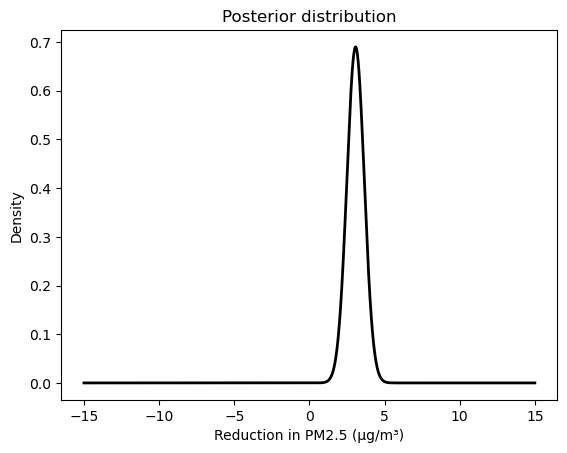

In [6]:
# Plot posterior distribution

x = np.linspace(-15, 15, 10000)
fig, ax = plt.subplots(1, 1)
plt.xlabel("Reduction in PM2.5 (µg/m³)")
plt.ylabel("Density")
plt.title('Posterior distribution')
ax.plot(x, post(x), 'k-', lw=2)
plt.show()

Our formal approach made use of the pilot study, and they were strong enough to support our prior belief, providing overall an estimate of a higher cost if the regulation is not implemented. What if the pilot collected 5 more measurements, but now the average reduction was only 1.8$\mu g/m^3$, and the standard deviation 3.7$\mu g/m^3$?

Posterior Mean Reduction: 1.93 µg/m³
Posterior Std Dev: 0.66 µg/m³
Expected Net Cost for Implementation (Action A): $613,743.29
Expected Net Cost for No Implementation (Action B): $386,318.16
Decision: Do not implement the regulation


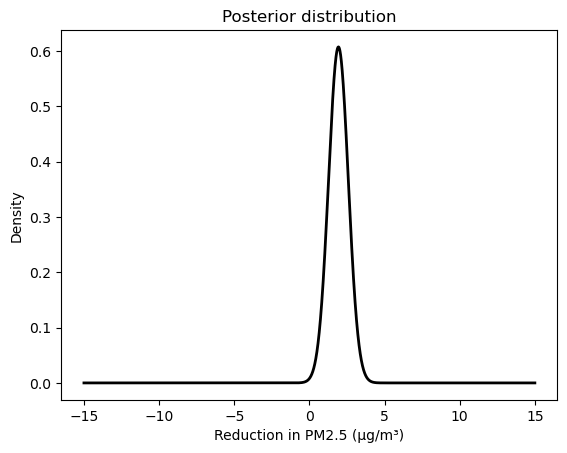

In [7]:
mu_data = 1.8
sigma_data = 3.7
n = 20

# Compute posterior parameters (Normal-Normal update based on the equations above)
sigma_post = (sigma_data**2 * sigma_prior**2) / (sigma_data**2 + n * sigma_prior**2)
mu_post = ((mu_prior / sigma_prior**2) + (n * mu_data / sigma_data**2)) * sigma_post

rv = norm(mu_post, sigma_post)

post = lambda x: rv.pdf(x)

# Calculate cost for implementing the regulation
l_a = lambda x: (implementation_cost - health_savings_per_unit * x) * post(x)

# Expected net cost for Action A
expected_net_cost_A = integrate.quad(l_a, -np.inf, np.inf)[0]


# Calculate cost for NOT implementing the regulation
l_b = lambda x: 0 if x <= 0 else (health_savings_per_unit * x)* post(x)

# Expected net cost for Action B
expected_net_cost_B = integrate.quad(l_b, -np.inf, np.inf)[0]


# Print results
print(f"Posterior Mean Reduction: {mu_post:.2f} µg/m³")
print(f"Posterior Std Dev: {sigma_post:.2f} µg/m³")
print(f"Expected Net Cost for Implementation (Action A): ${expected_net_cost_A:,.2f}")
print(f"Expected Net Cost for No Implementation (Action B): ${expected_net_cost_B:,.2f}")

decision = "Implement the regulation" if expected_net_cost_A < expected_net_cost_B else "Do not implement the regulation"
print(f"Decision: {decision}")

# Plot posterior distribution
x = np.linspace(-15, 15, 10000)
fig, ax = plt.subplots(1, 1)
plt.xlabel("Reduction in PM2.5 (µg/m³)")
plt.ylabel("Density")
plt.title('Posterior distribution')
ax.plot(x, post(x), 'k-', lw=2)
plt.show()

With these new measurements/evidence, our posterior belief on the impact of the new regulation is less strong and there is more uncertainty. This overall leads to a higher expected cost if the regulation is adopted.

You can experiment with changing the parameters of the setting (e.g., your prior belief) and explore how this changes your decision.  